In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use('default')

## `Problem 1 to 5`:

Dataset link: https://tinyurl.com/2fe6vz4u

**Add a label to every axis and add a proper title for the charts. Also add proper labels if there are multiple representations.** Then, you can customize it as your wish.

### **`Problem-1:`** Draw a line plot of which, the x-axis is the "Year" and the y-axis is sum of "PM2.5" of two countries Iran and China.

In [ ]:
# code here
cities = pd.read_csv('/content/List of most-polluted cities by particulate matter concentration - List of most-polluted cities by particulate matter concentration.csv')

In [ ]:
cities.head()

,Unnamed: 0,Position,Country,City/Town,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
0,0,1,India,Kanpur,2016,173,>75%,319,NaN,2018
1,1,2,India,Faridabad,2016,172,>75%,316,NaN,2018
2,2,3,India,Gaya,2016,149,50% -< 75%,275,NaN,2018
3,3,4,India,Varanasi,2016,146,>75%,260,NaN,2018
4,4,5,India,Patna,2016,144,>75%,266,NaN,2018


In [ ]:
iran_series = cities[cities['Country'] == 'Iran'].groupby('Country')['PM2.5'].sum()
iran_series

,PM2.5
Country,
Iran,1587


In [ ]:
china_series = cities[cities['Country'] == 'China'].groupby('Country')['PM2.5'].sum()
china_series

,PM2.5
Country,
China,14256


In [ ]:
filtered_cities = cities[cities['Country'].isin(['Iran','China'])]
filtered_cities

,Unnamed: 0,Position,Country,City/Town,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
18,18,19,China,Baoding,2016,93,NaN,147,NaN,2018
21,21,22,China,Jinan,2014,90,NaN,192,NaN,2018
22,22,23,China,Shijiazhuang,2015,89,NaN,147,NaN,2018
24,24,25,China,Hengshui,2016,87,NaN,143,NaN,2018
25,25,26,China,Xingtai,2016,87,NaN,186,NaN,2018
...,...,...,...,...,...,...,...,...,...,...
479,479,480,China,Huizhou,2016,27,NaN,45,NaN,2018
480,480,481,China,Ningde,2016,27,NaN,46,NaN,2018
481,481,482,China,Shenzhen,2016,27,NaN,42,NaN,2018
484,484,485,Iran,Hamadan,2016,27,NaN,61,NaN,2018


In [ ]:
result = filtered_cities.groupby(['Year', 'Country'])['PM2.5'].sum().unstack()
result

Country,China,Iran
Year,,
2012,NaN,37.0
2013,NaN,66.0
2014,2725.0,31.0
2015,425.0,NaN
2016,11106.0,1453.0


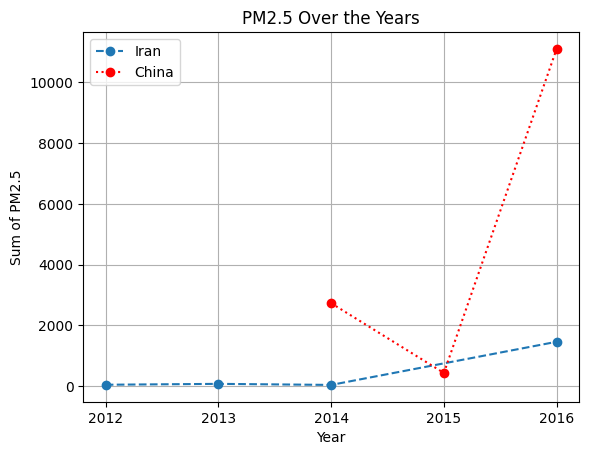

In [ ]:
iran_clean = result['Iran'].dropna()
china_clean = result['China'].dropna()

plt.plot(iran_clean.index, iran_clean, label='Iran', linestyle='dashed', marker='o')
plt.plot(china_clean.index, china_clean, label='China', linestyle='dotted', color='red', marker='o')

plt.xlabel('Year')
plt.ylabel('Sum of PM2.5')
plt.title('PM2.5 Over the Years')
#plt.yscale('log', base=10)
plt.xticks(result.index)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
res_df = cities[cities['Country'].isin(['Iran','China'])].groupby('Country')['PM2.5'].sum()
res_df

,PM2.5
Country,
China,14256
Iran,1587


/tmp/ipykernel_2106/1178083977.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


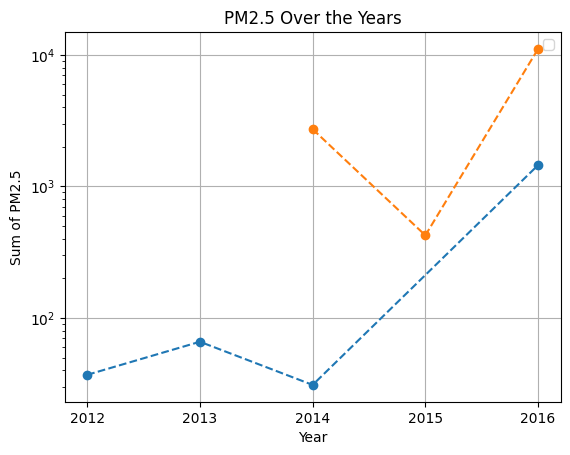

In [ ]:
result = cities[cities['Country'].isin(['Iran', 'China'])].groupby(['Year', 'Country'])['PM2.5'].sum().unstack()

# 2. Plot the columns directly
plt.plot(result['Iran'].dropna().index, result['Iran'].dropna(),linestyle='dashed',marker='o')
plt.plot(result['China'].dropna().index, result['China'].dropna(),linestyle='dashed',marker='o')

plt.xlabel('Year')
plt.ylabel('Sum of PM2.5')
plt.title('PM2.5 Over the Years')
plt.yscale('log', base=10)
plt.xticks(result.index)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
result

Country,China,Iran
Year,,
2012,NaN,37.0
2013,NaN,66.0
2014,2725.0,31.0
2015,425.0,NaN
2016,11106.0,1453.0


In [ ]:
filtered_cities = cities[cities['Country'].isin(['Iran','China'])]
res = filtered_cities.pivot_table(index='Country',values='PM2.5',columns='Year',aggfunc='sum').unstack(level=0).unstack(level=1)
res

Country,China,Iran
Year,,
2012,NaN,37.0
2013,NaN,66.0
2014,2725.0,31.0
2015,425.0,NaN
2016,11106.0,1453.0


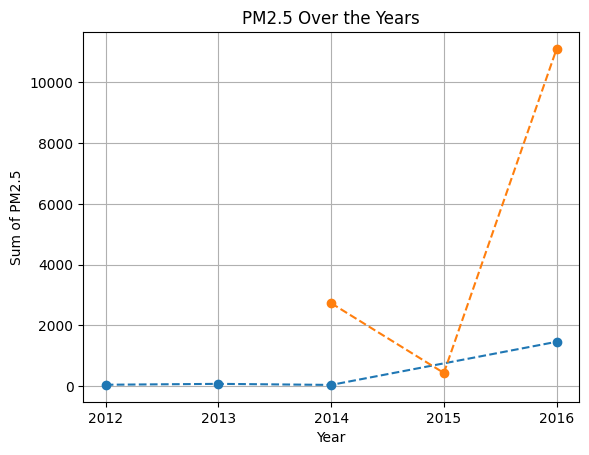

In [ ]:
plt.plot(res['Iran'].dropna().index, res['Iran'].dropna(),marker='o',linestyle='dashed')
plt.plot(res['China'].dropna().index, res['China'].dropna(),marker='o',linestyle='dashed')


plt.xlabel('Year')
plt.ylabel('Sum of PM2.5')
plt.title('PM2.5 Over the Years')
plt.xticks(res.index)
plt.grid(True)
plt.show()

### **`Problem-2:`** Draw a histogram of the  column "PM10" of which the y-axis represents the probability (see the documentation how to draw the probability).

In [ ]:
# code here
cities['PM10'].max()

540

Text(0.5, 1.0, 'Histogram of PM10')

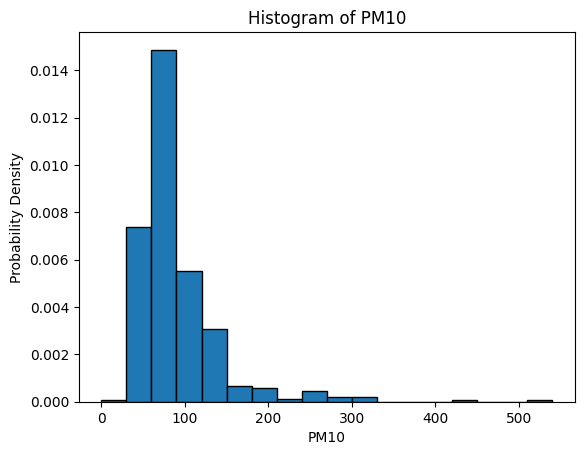

In [ ]:
plt.hist(cities['PM10'], bins = np.arange(0, cities['PM10'].max() + 30, 30), density=True, edgecolor='black')
plt.xlabel("PM10")
plt.ylabel("Probability Density")
plt.title("Histogram of PM10")

In [ ]:
pm10 = cities['PM10']
pm10.shape

(500,)

In [ ]:
one_like = np.ones_like(pm10)

In [ ]:
weights = np.ones_like(pm10) / len(pm10)
weights

array([0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002,
       0.002, 0.002,

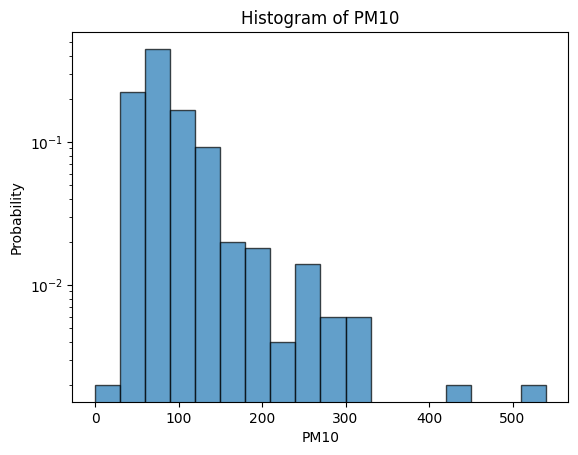

In [ ]:
plt.hist(pm10, bins = np.arange(0, cities['PM10'].max() + 30, 30), weights=weights, edgecolor='black', alpha=0.7, log=True)
plt.xlabel("PM10")
plt.ylabel("Probability")
plt.title("Histogram of PM10")
#plt.yscale('log',base=10)
plt.show()

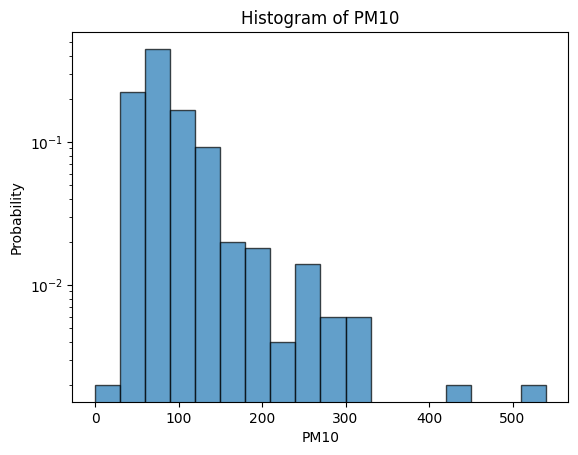

In [ ]:
plt.hist(pm10, bins = np.arange(0, cities['PM10'].max() + 30, 30), weights=weights, edgecolor='black', alpha=0.7, log=True)
## use log=Ture only in histogram
plt.xlabel("PM10")
plt.ylabel("Probability")
plt.title("Histogram of PM10")
#plt.yscale('log',base=10)
plt.show()

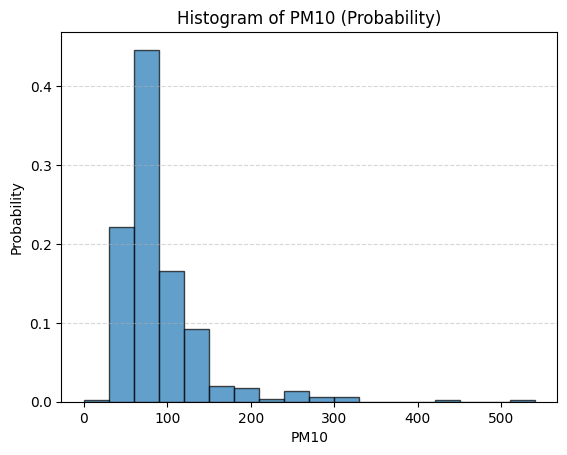

In [ ]:
# Plot the histogram using the computed fractional weights
plt.hist(pm10, bins=np.arange(0, cities['PM10'].max() + 30, 30), weights=weights, edgecolor='black', alpha=0.7)

# Label formatting
plt.xlabel("PM10")
plt.ylabel("Probability")  # Updated label
plt.title("Histogram of PM10 (Probability)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### **`Problem-3:`** Draw a scatter plot where x-axis represents "PM2.5" and y-axis represents "PM10" for two countries Poland and Chile.

In [ ]:
# code here
poland = cities[cities['Country'].isin(['Poland'])]
chile = cities[cities['Country'].isin(['Chile'])]

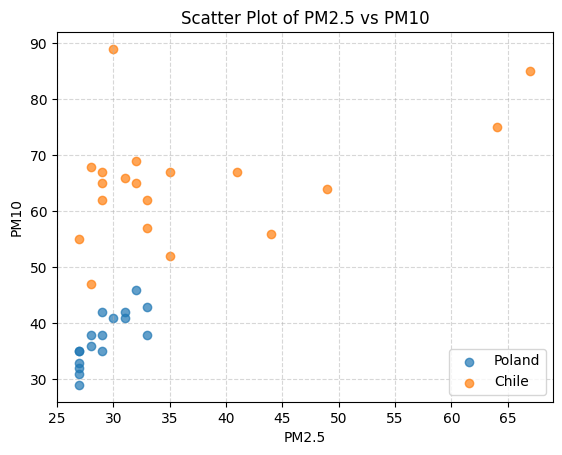

In [ ]:
plt.scatter(poland['PM2.5'],poland['PM10'], label="Poland", alpha=0.7)
plt.scatter(chile['PM2.5'],chile['PM10'], label="Chile", alpha=0.7)

plt.title('Scatter Plot of PM2.5 vs PM10')
plt.xlabel('PM2.5')
plt.ylabel('PM10')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

### **`Problem-4:`** Draw a pie chart of top 5 most frequent countries.

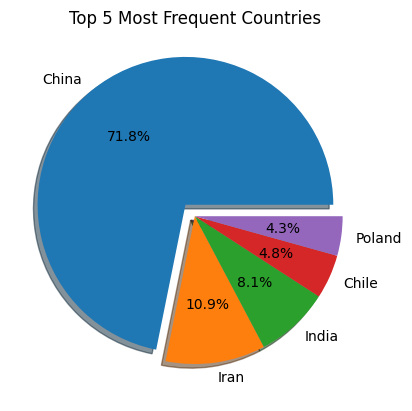

In [ ]:
# code here
top_5_countries = cities['Country'].value_counts().head(5)
plt.pie(top_5_countries, labels=top_5_countries.index, autopct='%1.1f%%', explode=(0.1,0,0,0,0), shadow=True)

plt.title('Top 5 Most Frequent Countries')
plt.show()

### **`Problem-5:`** Draw a bar chart which represents the counts of top 5 most frequent countries.



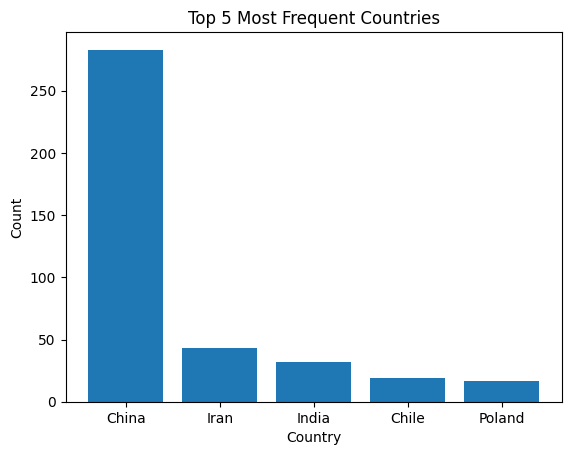

In [ ]:
plt.bar(top_5_countries.index, height=top_5_countries.values)
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Top 5 Most Frequent Countries')
plt.show()

##`Problem 6-10`
Data Set - https://docs.google.com/spreadsheets/d/e/2PACX-1vTJh6X4_mqixWsfK9mgkllGQkKYW9Wj9kOIMGY2uYsWeS8n5np87DO-SDGQWJ1HXEnxiOVFVzYFYEcR/pub?gid=558678488&single=true&output=csv

This is a Sales data of any company in a Year.


###`Problem-6`
Show a line plot of Total Profit for each month with below styling.
* Dotted Line
* Line Color Blue
* Show Legend at top left
* Circle Marker

In [ ]:
sales_df = pd.read_csv(r"https://docs.google.com/spreadsheets/d/e/2PACX-1vTJh6X4_mqixWsfK9mgkllGQkKYW9Wj9kOIMGY2uYsWeS8n5np87DO-SDGQWJ1HXEnxiOVFVzYFYEcR/pub?gid=558678488&single=true&output=csv")

In [ ]:
sales_df.head()

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600


In [ ]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   month_number  12 non-null     int64
 1   facecream     12 non-null     int64
 2   facewash      12 non-null     int64
 3   toothpaste    12 non-null     int64
 4   bathingsoap   12 non-null     int64
 5   shampoo       12 non-null     int64
 6   moisturizer   12 non-null     int64
 7   total_units   12 non-null     int64
 8   total_profit  12 non-null     int64
dtypes: int64(9)
memory usage: 996.0 bytes


In [ ]:
sales_df['month_name'] = pd.to_datetime(sales_df['month_number'], format='%m').dt.month_name()
sales_df

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit,month_name
0,1,2500,1500,5200,9200,1200,1500,21100,211000,January
1,2,2630,1200,5100,6100,2100,1200,18330,183300,February
2,3,2140,1340,4550,9550,3550,1340,22470,224700,March
3,4,3400,1130,5870,8870,1870,1130,22270,222700,April
4,5,3600,1740,4560,7760,1560,1740,20960,209600,May
5,6,2760,1555,4890,7490,1890,1555,20140,201400,June
6,7,2980,1120,4780,8980,1780,1120,29550,295500,July
7,8,3700,1400,5860,9960,2860,1400,36140,361400,August
8,9,3540,1780,6100,8100,2100,1780,23400,234000,September
9,10,1990,1890,8300,10300,2300,1890,26670,266700,October


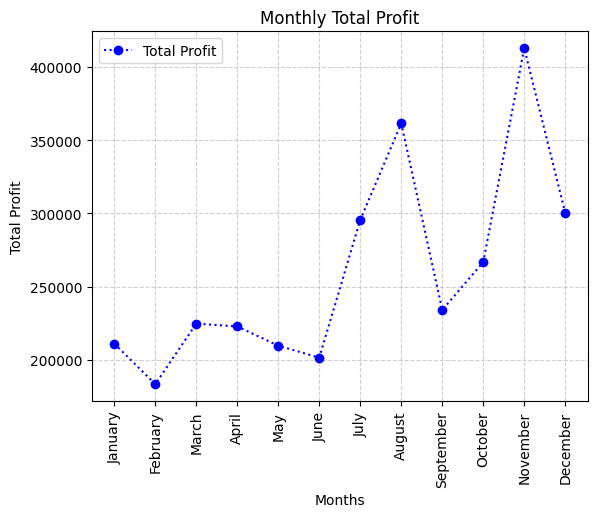

In [ ]:
plt.plot(
         sales_df['month_name'],
         sales_df['total_profit'],
         linestyle='dotted',
         color='blue', marker='o',
         alpha=1,
         label='Total Profit'
         )

plt.title('Monthly Total Profit')
plt.xlabel('Months')
plt.xticks(rotation='vertical')
plt.ylabel('Total Profit')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.show()

###`Problem-7`
Show sales of each product in march month as pie chart.
* Show Percentage value
* Give Title "Sales in March"
* Explode ToothPaste with shadow

In [ ]:
march_df = sales_df.loc[2][1:7]
march_sales = march_df.reset_index(name='sales').rename(columns={'index' : 'product'})
march_sales

,product,sales
0,facecream,2140
1,facewash,1340
2,toothpaste,4550
3,bathingsoap,9550
4,shampoo,3550
5,moisturizer,1340


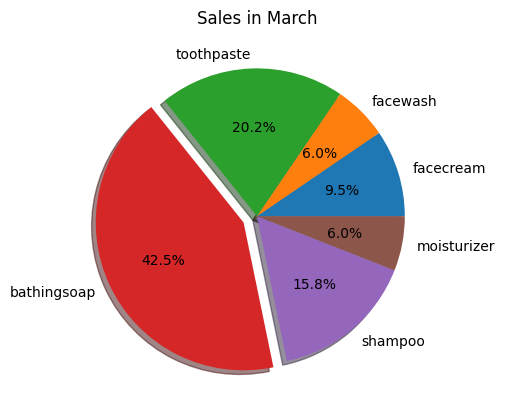

In [ ]:
plt.pie(
    march_sales['sales'],
    labels=march_sales['product'],
    autopct='%1.1f%%',
    explode=(0,0,0,0.1,0,0),
    shadow=True
)

plt.title('Sales in March')
plt.show()

###`Problem-8` Multiline Plot of all products sales.
* Give different styes for each products
* Add legend at top right

In [ ]:
sales_df

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit,month_name
0,1,2500,1500,5200,9200,1200,1500,21100,211000,January
1,2,2630,1200,5100,6100,2100,1200,18330,183300,February
2,3,2140,1340,4550,9550,3550,1340,22470,224700,March
3,4,3400,1130,5870,8870,1870,1130,22270,222700,April
4,5,3600,1740,4560,7760,1560,1740,20960,209600,May
5,6,2760,1555,4890,7490,1890,1555,20140,201400,June
6,7,2980,1120,4780,8980,1780,1120,29550,295500,July
7,8,3700,1400,5860,9960,2860,1400,36140,361400,August
8,9,3540,1780,6100,8100,2100,1780,23400,234000,September
9,10,1990,1890,8300,10300,2300,1890,26670,266700,October


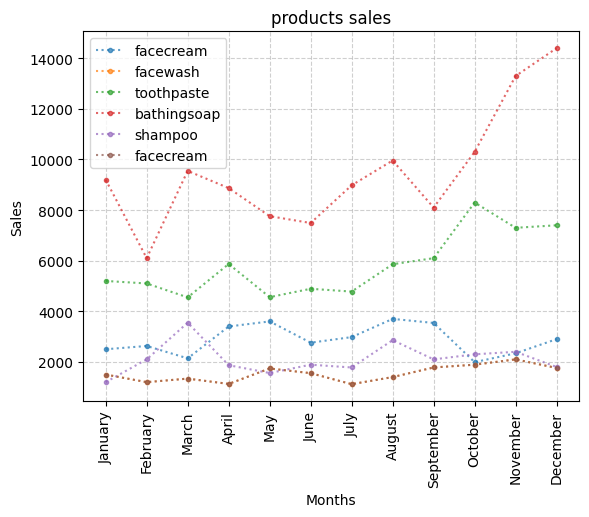

In [ ]:
from matplotlib import legend
plt.plot(sales_df['month_name'], sales_df['facecream'], linestyle='dotted', marker='o', markersize=3, alpha=0.7, label='facecream')
plt.plot(sales_df['month_name'], sales_df['facewash'], linestyle='dotted', marker='o', markersize=3, alpha=0.7, label='facewash')
plt.plot(sales_df['month_name'], sales_df['toothpaste'], linestyle='dotted', marker='o', markersize=3, alpha=0.7, label='toothpaste')
plt.plot(sales_df['month_name'], sales_df['bathingsoap'], linestyle='dotted', marker='o', markersize=3, alpha=0.7, label='bathingsoap')
plt.plot(sales_df['month_name'], sales_df['shampoo'], linestyle='dotted', marker='o', markersize=3, alpha=0.7, label='shampoo')
plt.plot(sales_df['month_name'], sales_df['moisturizer'], linestyle='dotted', marker='o', markersize=3, alpha=0.7, label='facecream')

plt.title('products sales')
plt.xlabel('Months')
plt.xticks(rotation='vertical')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.show()

###`Problem-9` Show Quarter wise Sales data for all products as multi Bar chart.


In [ ]:
#sales_df['quarter'] = pd.to_datetime(sales_df['month_name'] + ' 2026').dt.quarter
sales_df['quarter'] = ((sales_df['month_number'] - 1) // 3) + 1
sales_df

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit,month_name,quarter
0,1,2500,1500,5200,9200,1200,1500,21100,211000,January,1
1,2,2630,1200,5100,6100,2100,1200,18330,183300,February,1
2,3,2140,1340,4550,9550,3550,1340,22470,224700,March,1
3,4,3400,1130,5870,8870,1870,1130,22270,222700,April,2
4,5,3600,1740,4560,7760,1560,1740,20960,209600,May,2
5,6,2760,1555,4890,7490,1890,1555,20140,201400,June,2
6,7,2980,1120,4780,8980,1780,1120,29550,295500,July,3
7,8,3700,1400,5860,9960,2860,1400,36140,361400,August,3
8,9,3540,1780,6100,8100,2100,1780,23400,234000,September,3
9,10,1990,1890,8300,10300,2300,1890,26670,266700,October,4


In [ ]:
#temp = sales_df.columns[1:7]
#sales_df.groupby('quarter')[temp].sum()
quater_sales = sales_df.pivot_table(index='quarter', values=sales_df.iloc[:,1:7], aggfunc='sum')
quater_sales

,bathingsoap,facecream,facewash,moisturizer,shampoo,toothpaste
quarter,,,,,,
1,24850,7270,4040,4040,6850,14850
2,24120,9760,4425,4425,5320,15320
3,27040,10220,4300,4300,6740,16740
4,38000,7230,5750,5750,6500,23000


array([-0.3,  0.7,  1.7,  2.7])

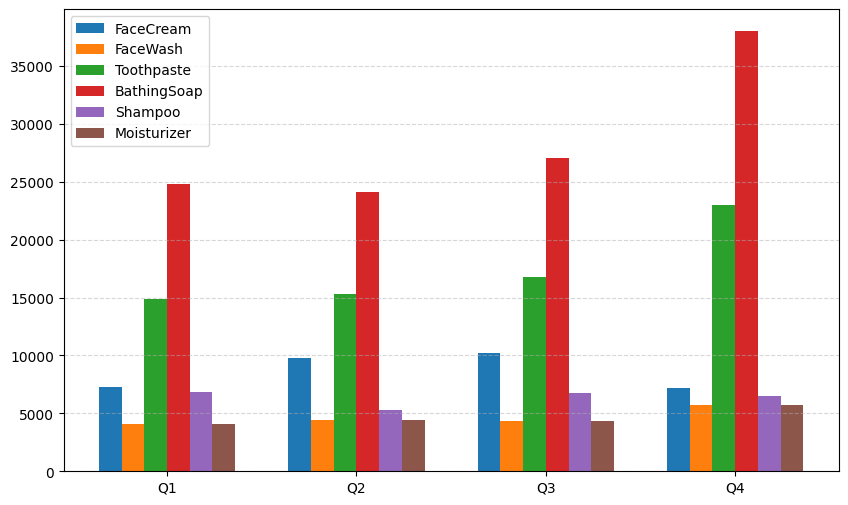

In [ ]:
x = np.arange(4)
width = 0.12  # Width of each individual bar

plt.figure(figsize=(10, 6))

# Manually shift each of your 6 columns along the X axis
plt.bar(x - 2.5*width, quater_sales['facecream'], width, label='FaceCream')
plt.bar(x - 1.5*width, quater_sales['facewash'], width, label='FaceWash')
plt.bar(x - 0.5*width, quater_sales['toothpaste'], width, label='Toothpaste')
plt.bar(x + 0.5*width, quater_sales['bathingsoap'], width, label='BathingSoap')
plt.bar(x + 1.5*width, quater_sales['shampoo'], width, label='Shampoo')
plt.bar(x + 2.5*width, quater_sales['moisturizer'], width, label='Moisturizer')

# Layout adjustments
plt.xticks(x, ['Q1', 'Q2', 'Q3', 'Q4'])
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

#plt.show()
x - 2.5*width

/tmp/ipykernel_2106/1861769111.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


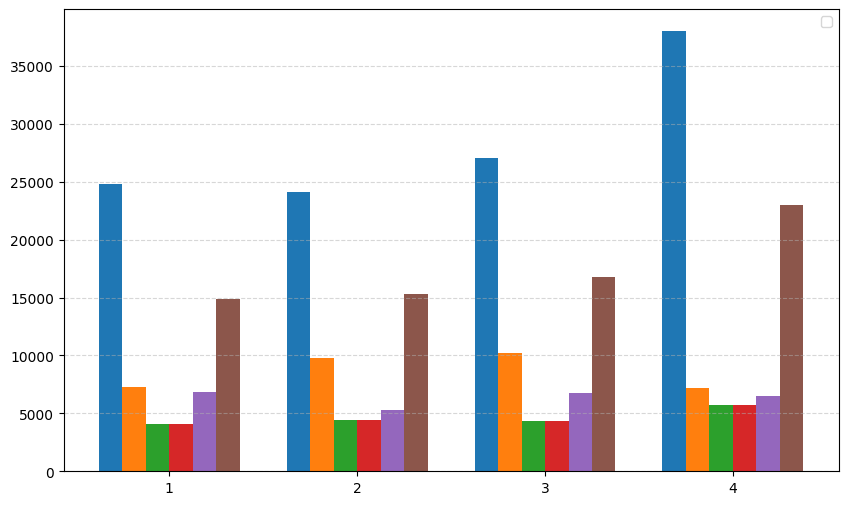

In [ ]:
x = np.arange(len(quater_sales.index)) * 4
width = 0.50
plt.figure(figsize=(10, 6))

plt.bar(x, quater_sales['bathingsoap'], width=width)
plt.bar(x + 0.50, quater_sales['facecream'], width=width)
plt.bar(x + 1.00, quater_sales['facewash'], width=width)
plt.bar(x + 1.50, quater_sales['moisturizer'], width=width)
plt.bar(x + 2.00, quater_sales['shampoo'], width=width)
plt.bar(x + 2.50, quater_sales['toothpaste'], width=width)

plt.xticks(x + 1.25, quater_sales.index)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

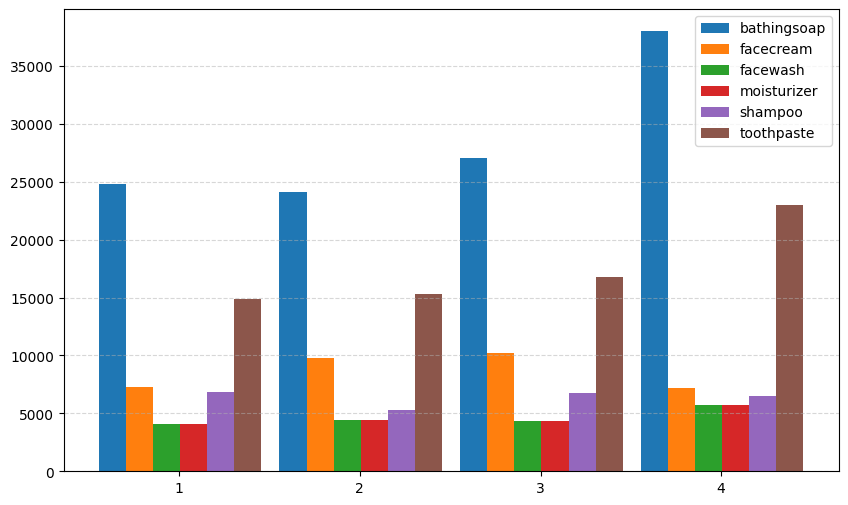

In [ ]:
x = np.arange(len(quater_sales.index))
width = 1.8
plt.figure(figsize=(10, 6))

plt.bar(np.arange(len(quater_sales.index)), quater_sales['bathingsoap'], width=0.15, label='bathingsoap')
plt.bar(np.arange(len(quater_sales.index))+ 0.15, quater_sales['facecream'], width=0.15, label='facecream')
plt.bar(np.arange(len(quater_sales.index)) + 0.30, quater_sales['facewash'], width=0.15, label='facewash')
plt.bar(np.arange(len(quater_sales.index)) + 0.45, quater_sales['moisturizer'], width=0.15, label='moisturizer')
plt.bar(np.arange(len(quater_sales.index)) + 0.60, quater_sales['shampoo'], width=0.15, label='shampoo')
plt.bar(np.arange(len(quater_sales.index)) + 0.75, quater_sales['toothpaste'], width=0.15, label='toothpaste')

plt.xticks(x + 0.37, quater_sales.index)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

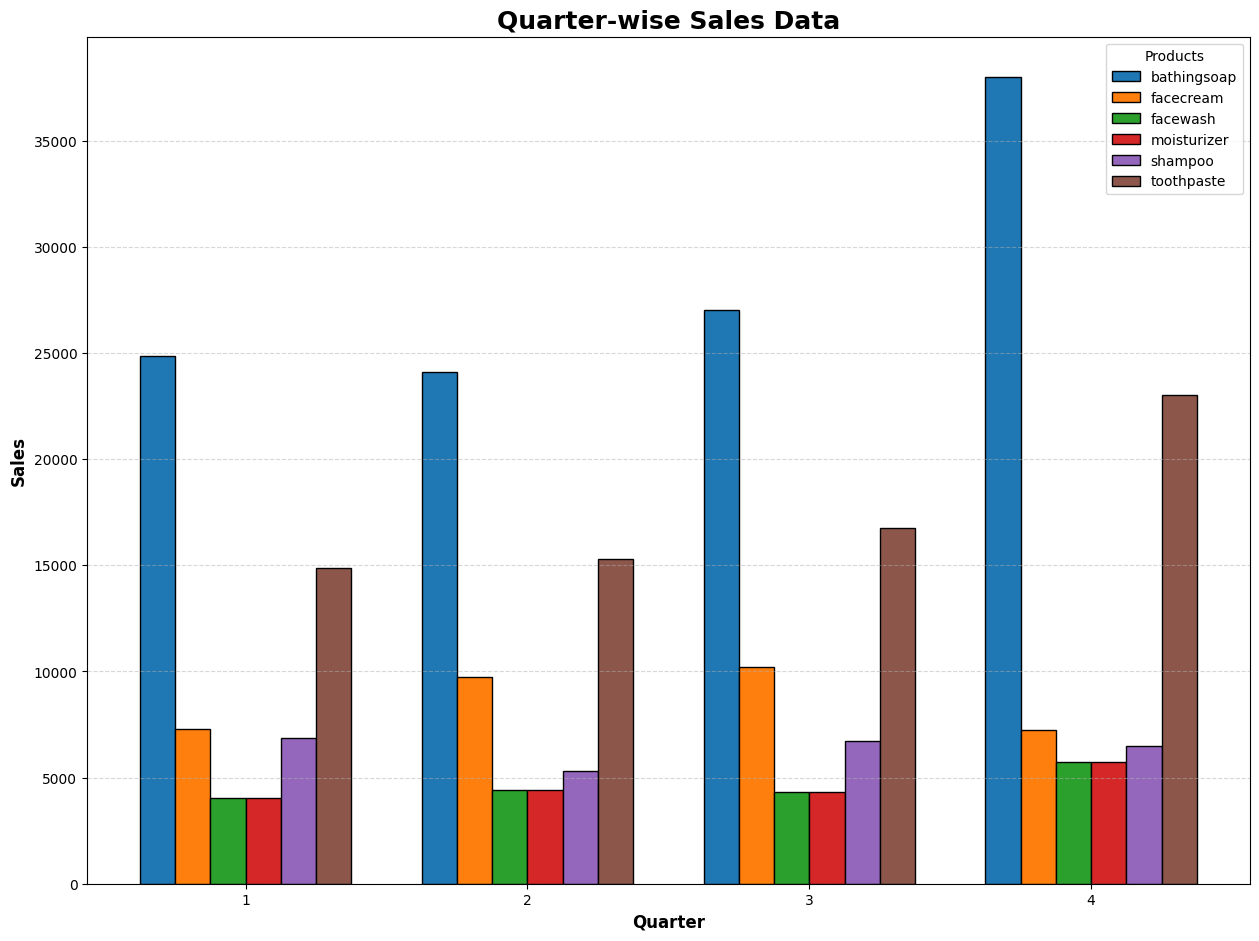

In [ ]:
temp = np.arange(len(quater_sales.index)) * 2
width_bar = 0.25
plt.figure(figsize=(15, 11))

for i, col in enumerate(quater_sales.columns):
	plt.bar(temp + i*width_bar, quater_sales[col], width=width_bar, edgecolor='black', label=col)

plt.xticks(temp + (len(quater_sales.columns) - 1) * width_bar/2, quater_sales.index)
plt.legend(title='Products')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xlabel('Quarter', fontweight='bold', fontsize=12)
plt.ylabel('Sales', fontweight='bold', fontsize=12)
plt.title('Quarter-wise Sales Data', fontweight='bold', fontsize=18)
plt.show()

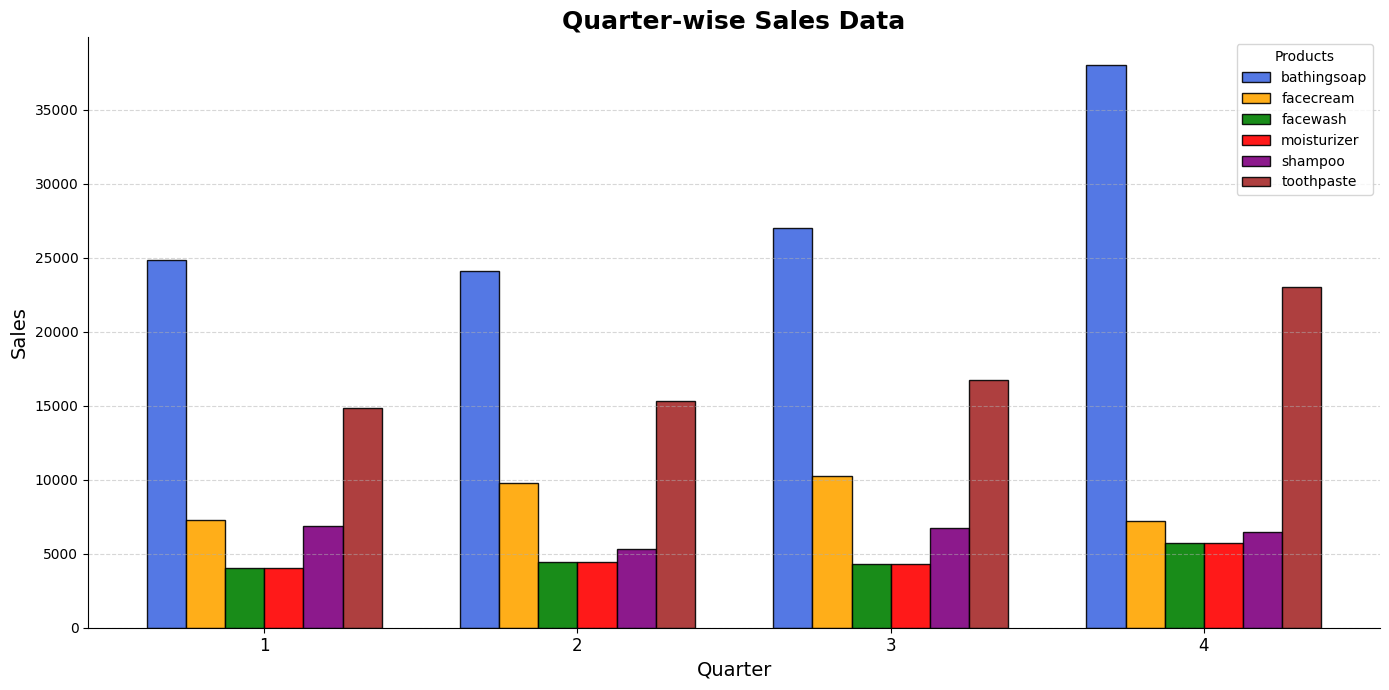

In [ ]:
temp = np.arange(len(quater_sales.index)) * 2
width_bar = 0.25

colors = ['royalblue', 'orange', 'green',
          'red', 'purple', 'brown']

plt.figure(figsize=(14,7))

for i, col in enumerate(quater_sales.columns):
    plt.bar(temp + i*width_bar,
            quater_sales[col],
            width=width_bar,
            color=colors[i],
            edgecolor='black',
            linewidth=1,
            alpha=0.9,
            label=col)

plt.xticks(
    temp + (len(quater_sales.columns)-1)*width_bar/2,
    quater_sales.index,
    fontsize=12
)

plt.title('Quarter-wise Sales Data',
          fontsize=18,
          fontweight='bold')

plt.xlabel('Quarter',
           fontsize=14)

plt.ylabel('Sales',
           fontsize=14)

plt.grid(axis='y',
         linestyle='--',
         alpha=0.5)

plt.legend(title='Products')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

###`Problem-10` Plot Stacked Bar chart quarter wise for each product.

In [ ]:
sales_df

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit,month_name,quarter
0,1,2500,1500,5200,9200,1200,1500,21100,211000,January,1
1,2,2630,1200,5100,6100,2100,1200,18330,183300,February,1
2,3,2140,1340,4550,9550,3550,1340,22470,224700,March,1
3,4,3400,1130,5870,8870,1870,1130,22270,222700,April,2
4,5,3600,1740,4560,7760,1560,1740,20960,209600,May,2
5,6,2760,1555,4890,7490,1890,1555,20140,201400,June,2
6,7,2980,1120,4780,8980,1780,1120,29550,295500,July,3
7,8,3700,1400,5860,9960,2860,1400,36140,361400,August,3
8,9,3540,1780,6100,8100,2100,1780,23400,234000,September,3
9,10,1990,1890,8300,10300,2300,1890,26670,266700,October,4


In [ ]:
quater_sales

,bathingsoap,facecream,facewash,moisturizer,shampoo,toothpaste
quarter,,,,,,
1,24850,7270,4040,4040,6850,14850
2,24120,9760,4425,4425,5320,15320
3,27040,10220,4300,4300,6740,16740
4,38000,7230,5750,5750,6500,23000


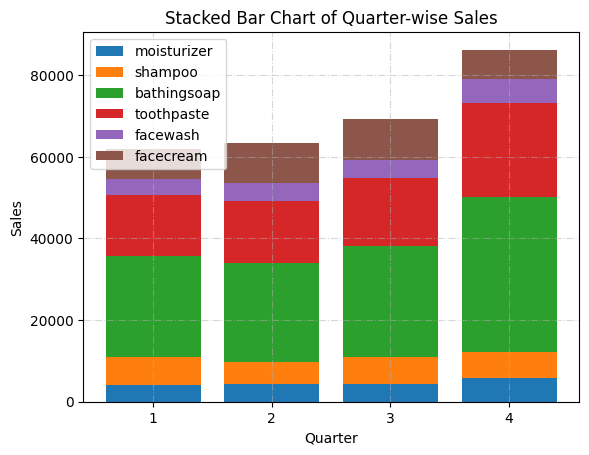

In [ ]:
plt.bar(quater_sales.index, quater_sales['moisturizer'], label='moisturizer')
plt.bar(quater_sales.index, quater_sales['shampoo'], bottom=quater_sales['moisturizer'], label='shampoo')
plt.bar(quater_sales.index, quater_sales['bathingsoap'], bottom=quater_sales['moisturizer'] + quater_sales['shampoo'], label='bathingsoap')
plt.bar(quater_sales.index, quater_sales['toothpaste'], bottom=quater_sales['moisturizer'] + quater_sales['shampoo'] + quater_sales['bathingsoap'], label='toothpaste')
plt.bar(quater_sales.index, quater_sales['facewash'], bottom=quater_sales['moisturizer'] + quater_sales['shampoo'] + quater_sales['bathingsoap'] + quater_sales['toothpaste'], label='facewash')
plt.bar(quater_sales.index, quater_sales['facecream'], bottom=quater_sales['moisturizer'] + quater_sales['shampoo'] + quater_sales['bathingsoap'] + quater_sales['toothpaste'] + quater_sales['facewash'], label='facecream')


plt.title('Stacked Bar Chart of Quarter-wise Sales')
plt.xlabel('Quarter')
plt.ylabel('Sales')
plt.xticks(quater_sales.index)
plt.grid(linestyle='-.', alpha=0.5)
plt.legend()
plt.show()

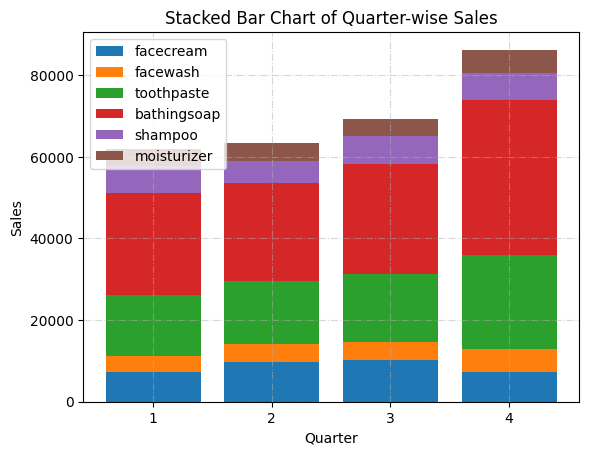

In [ ]:
plt.bar(quater_sales.index, quater_sales['facecream'], label='facecream')
plt.bar(quater_sales.index, quater_sales['facewash'], bottom=quater_sales['facecream'], label='facewash')
plt.bar(quater_sales.index, quater_sales['toothpaste'], bottom=quater_sales['facewash'] + quater_sales['facecream'], label='toothpaste')
plt.bar(quater_sales.index, quater_sales['bathingsoap'], bottom=quater_sales['toothpaste'] + quater_sales['facewash'] + quater_sales['facecream'], label='bathingsoap')
plt.bar(quater_sales.index, quater_sales['shampoo'], bottom=quater_sales['bathingsoap'] + quater_sales['toothpaste'] + quater_sales['facewash'] + quater_sales['facecream'], label='shampoo')
plt.bar(quater_sales.index, quater_sales['moisturizer'], bottom=quater_sales['shampoo'] + quater_sales['bathingsoap'] + quater_sales['toothpaste'] + quater_sales['facewash'] + quater_sales['facecream'], label='moisturizer')

plt.title('Stacked Bar Chart of Quarter-wise Sales')
plt.xlabel('Quarter')
plt.ylabel('Sales')
plt.xticks(quater_sales.index)
plt.grid(linestyle='-.', alpha=0.5)
plt.legend()
plt.show()

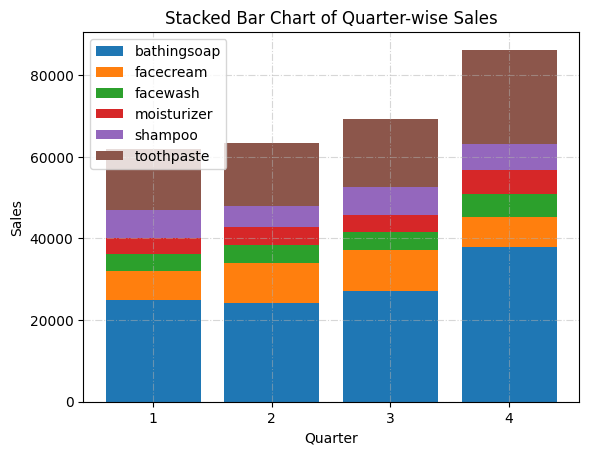

In [ ]:
base_value = 0
for col in quater_sales.columns:
	plt.bar(
		quater_sales.index,
		quater_sales[col],
		bottom = base_value,
    label=col
		)
	base_value += quater_sales[col]

plt.title('Stacked Bar Chart of Quarter-wise Sales')
plt.xlabel('Quarter')
plt.ylabel('Sales')
plt.xticks(quater_sales.index)
plt.grid(linestyle='-.', alpha=0.5)
plt.legend()
plt.show()